## Depth anything based approach

This notebook uses depth anything v2 in order to estimate how well it performes for object specific depth estimation. 

Before running make sure to have followed install instructions that are in the readme file under set up.

In [8]:
# GENERAL IMPORTS
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import time
import torch
import gc
import os
import pandas as pd
from IPython.display import clear_output

import torchvision
from torchvision import transforms
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

from utils import getDevice, collate_fn
from depth_anything_3.api import DepthAnything3


In [9]:
DEVICE = getDevice()
HEIGHT = 376
WIDTH = 1242
TARGET_TYPES = ['Car']
BATCH_SIZE = 4
NUM_WORKERS = 4

In [10]:
#this is a test sample to see if the code actually works mostly copied from the official website

# Load model from Hugging Face Hub
device = getDevice()
depthAnything3 = DepthAnything3.from_pretrained("depth-anything/da3metric-large")
depthAnything3 = depthAnything3.to(device=device)

# Run inference on images
images = ["../imgs/image1.jpg"]  # List of image paths, PIL Images, or numpy arrays
prediction = depthAnything3.inference(
    images
)

# Access results
print(prediction.depth.shape)        # Depth maps: [N, H, W] float32
print("intrinsics:", prediction.intrinsics)
print("extrinsics:", prediction.extrinsics)


[INFO ] using MLP layer as FFN
[INFO ] Processed Images Done taking 0.07349276542663574 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.3741753101348877 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0012693405151367188 seconds
(1, 504, 504)
intrinsics: None
extrinsics: None


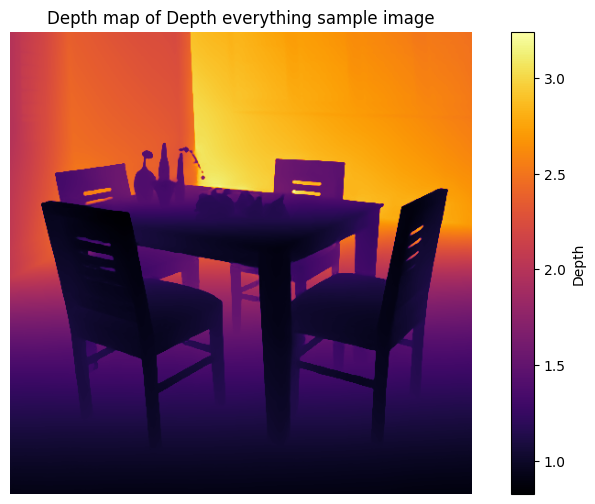

In [11]:
depth = prediction.depth[0] #image from the list

plt.figure(figsize=(10, 6))
plt.imshow(depth, cmap='inferno')  # or 'magma', 'plasma', 'turbo'
plt.colorbar(label='Depth')
plt.title('Depth map of Depth everything sample image')
plt.axis('off')
plt.show()

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((HEIGHT, WIDTH))
])

#DATASET IS LOADED AND DATALOADER IS CREATED

kitty_dataset =torchvision.datasets.Kitti(root="../datasets/", train=True,transform=transform, download=True)
kittty_dataloader = torch.utils.data.DataLoader(
    kitty_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

KITTY_LENGTH = len(kitty_dataset)
BATCH_COUNT = KITTY_LENGTH // BATCH_SIZE + (KITTY_LENGTH % BATCH_SIZE > 0)
print(f"KITTY dataset is length: {KITTY_LENGTH}\nDataloader has length: {len(kittty_dataloader)}\nBatch count {BATCH_COUNT}")

#I try a single batch to analyze the data structure and types
images, targets_batch = next(iter(kittty_dataloader))
print(f"Type of the images data is: {type(images)} type of image {type(images[0])} len: {len(images)} and type of the target is {type(targets_batch)} of len {len(targets_batch)}")

KITTY dataset is length: 7481
Dataloader has length: 1871
Batch count 1871
Type of the images data is: <class 'list'> type of image <class 'torch.Tensor'> len: 4 and type of the target is <class 'list'> of len 4


In [13]:
def extract_crops_depth(images_batch, targets_batch):
    # 1 IMAGES
    stacked_images = torch.stack(images_batch)
    image_list = [
        (img.permute(1,2,0).cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
        for img in images_batch
    ]
    stacked_depths = depthAnything3.inference(image_list).depth
    depths_h = stacked_depths.shape[1]
    depths_w = stacked_depths.shape[2]

    img_h = stacked_images.shape[2]
    img_w = stacked_images.shape[3]

    x_scaling = depths_w/img_w
    y_scaling = depths_h/img_h

    print(f"Depths dim: (H,W): ({depths_h},{depths_w}) img: ({img_h}, {img_w}) type of images is {type(stacked_depths)} {type(stacked_depths[0])}")
    # 2,3 BOXES and DEPTHS
    boxes =[]
    depths = []
    skip = []
    image_indicies = set(range(len(images_batch)))
    keep=[]
    for i, targets in enumerate(targets_batch):
        boxes_with_target = [torch.tensor(target["bbox"], dtype=torch.int32) for target in targets if target["type"] in TARGET_TYPES]
        depths_with_target = [target["location"][2] for target in targets if target["type"] in TARGET_TYPES]
        if len(boxes_with_target) > 0:
            boxes.append(torch.stack(boxes_with_target))
            depths.append(torch.Tensor(depths_with_target))
        else:
            skip.append(i)

    # 3.5 check that there is actually data 
    if len(boxes) == 0:
        print("No boxes found in this batch, skipping...")
        del boxes, images_batch, targets_batch
        gc.collect()
        return -1, -1

    #3.6 skip images that we do not want and add the depths
    keep = list(image_indicies - set(skip))
    stacked_depths = stacked_depths[keep,:,:]
    depths = torch.cat(depths).cpu()

    
    # 4 crop the images to a specific size
    depths_mean =[]
    for i in range(stacked_depths.shape[0]):
        # the current data is fetched
        image = stacked_depths[i]
        boxes_cur = boxes[i]

        #images are copped to the box
        for box in boxes_cur:
            x1,y1,x2,y2 = box.tolist()
            x1 = int(x1*x_scaling)
            x2 = int(x2*x_scaling)
            y1 = int(y1*y_scaling)
            y2 = int(y2*y_scaling)
            
            crop_np = image[y1:y2, x1:x2]
            depths_mean.append(crop_np.mean().item())
            #print(f"crop mean is {crop_np.nanmean()}")
            #print(f"x1: {x1}, x2 {x2}, y1 {y1}, y2 {y2}")
            del crop_np

    #exit function and clear the local variables
    del boxes, stacked_images, images_batch, targets_batch
    return depths.tolist(), depths_mean

def extract_crops(loader: DataLoader):
    """
    Extract the crops before the embeddings are retrieved.

    Args:
        loader: dataloader for the dataset
    """
    depths_true_all = []
    depths_mean_all = []
    counter = 0
    
    for images_batch, targets_batch in loader:
        #preporcess the data, format it in a way that is expected by the model===================
        clear_output(wait=True)
        print(f"Batch {counter} in progress; ({counter/len(loader)*100:.2f}%);")

        #extract boxes and depths to be added and saved==========================================
        depths, depths_mean = extract_crops_depth(images_batch, targets_batch)
        if depths_mean==-1 and depths==-1:
            continue
        depths_true_all.extend(depths)
        depths_mean_all.extend(depths_mean)

        #clear the variables and incremenet the counter===========================================
        del depths, depths_mean
        counter+=1

    gc.collect() 
    return depths_true_all, depths_mean_all

In [14]:
depths_true, depths_mean = extract_crops(kittty_dataloader)

Batch 1869 in progress; (99.89%);
[INFO ] Processed Images Done taking 0.029365062713623047 seconds. Shape:  torch.Size([1, 3, 154, 504])
[INFO ] Model Forward Pass Done. Time: 0.6762115955352783 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0014226436614990234 seconds
Depths dim: (H,W): (154,504) img: (376, 1242) type of images is <class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [ ]:
print(depths_mean)
print(depths_true)

print(f"type check: mean_d-{type(depths_mean)} mean_t-{type(depths_true)}\ntype of content: {type(depths_mean[0])} {type(depths_true[0])}")

[48.97263717651367, 12.790926933288574, 43.393798828125, 52.03439712524414, 22.610462188720703, 26.185497283935547, 31.294849395751953, 39.7938346862793, 9.794580459594727, 15.587023735046387, 13.238334655761719, 14.736048698425293, 24.031442642211914, 65.68933868408203, 32.4370002746582, 38.89837646484375, 13.154095649719238, 50.80476760864258, 9.998929977416992, 26.616186141967773, 21.442716598510742, 28.26313591003418, 41.10531997680664, 19.09408950805664, 41.477088928222656, 68.1032485961914, 49.96907424926758, 52.984291076660156, 16.94558334350586, 13.295092582702637, 53.050113677978516, 8.93994426727295, 4.945988178253174, 19.270050048828125, 24.10433578491211, 27.175643920898438, 4.880274772644043, 8.373619079589844, 8.85849380493164, 13.716742515563965, 13.222387313842773, 18.243114471435547, 67.0944595336914, 37.83140563964844, 30.90645408630371, 37.74641799926758, 43.22314453125, 40.76169967651367, 8.625704765319824, 19.583595275878906, 34.080562591552734, 31.456859588623047,

In [26]:
loss_fn = nn.L1Loss()

depths_mean_np = np.array(depths_mean)
depths_true_np = np.array(depths_true)

mask = ~np.isnan(depths_mean_np) & ~np.isnan(depths_true_np)

depths_mean_clean = depths_mean_np[mask]
depths_true_clean = depths_true_np[mask]

print(f"nan count is {np.sum(np.isnan(depths_mean_np))} len {len(depths_mean_np)} and sum {np.sum(depths_mean_np)}")
mae = loss_fn(torch.tensor(depths_mean_clean), torch.tensor(depths_true_clean))
print(f"MAE loss is {mae} m")

nan count is 2 len 28742 and sum nan
MAE loss is 4.134068968860989 m
